# Hands-on AI: Exact Greeks and Sensitivity Analysis via PyTorch Autograd

This notebook accompanies **Chapter 4: Turning Change into Math**, section **"Machine Learning Bridge: Itô's Calculus and Automatic Differentiation"**.

## The Financial Challenge: Greeks and the Finite Difference Dilemma
In mortgage desk risk management and fixed-income valuation, portfolio managers require sensitivities to assess market risk:
- **Delta ($\Delta = \frac{\partial P}{\partial r}$)**: First derivative with respect to interest rate shifts (related to DV01);
- **Gamma ($\Gamma = \frac{\partial^2 P}{\partial r^2}$)**: Second derivative measuring the curvature of the price-rate curve (related to Convexity);
- **Multi-Curve Sensitivities**: Key-Rate Durations (KRD) requiring partial derivatives across $K = 10 \dots 30$ curve tenors.

### The Classical Numerical Bumping Headache
To compute Greeks numerically, desks traditionally apply **central finite differences**:
$$\Delta \approx \frac{P(r + \epsilon) - P(r - \epsilon)}{2 \epsilon}, \quad \Gamma \approx \frac{P(r + \epsilon) - 2P(r) + P(r - \epsilon)}{\epsilon^2}$$

This method suffers from two structural flaws:
1. **The Step-Size Dilemma**: If $\epsilon$ is too large (e.g. 10 bp), second-order Taylor truncation error corrupts the derivative. If $\epsilon$ is too small (e.g. $10^{-6}$), floating-point roundoff cancellation explodes, especially for second derivatives where division by $\epsilon^2$ magnifies numerical noise.
2. **Computational Inefficiency**: For $K$ risk factors, computing Delta and Gamma requires re-running the pricing engine $2K + 1$ times, incurring heavy computational cost.

## The Autograd Revolution: Reverse-Mode Differentiation
Modern machine learning frameworks like `PyTorch` implement **Automatic Differentiation (Autograd)** on directed acyclic computation graphs:
- Computes exact analytical derivatives to machine precision ($10^{-16}$) with zero truncation error;
- Computes sensitivities across **all** $K$ input factors simultaneously in a single $\mathcal{O}(1)$ reverse pass!

## What This Notebook Covers
1. Implementing an autograd-differentiable bond pricing model under the Vasicek framework in PyTorch;
2. Computing exact Delta (first derivative) and Gamma (second derivative) via `torch.autograd.grad`;
3. Exposing the U-shaped error curve of finite differences (truncation error vs floating-point cancellation);
4. Benchmarking computational scaling: $\mathcal{O}(K)$ for finite differences vs $\mathcal{O}(1)$ for reverse-mode autograd;
5. Visualizing the complete comparative dashboard for desk risk management.


In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch

# Cap CPU threads for deterministic performance on multi-core systems
torch.set_num_threads(4)

print("PyTorch version:", torch.__version__)
print("Using CPU threads:", torch.get_num_threads())


PyTorch version: 2.10.0+cu128
Using CPU threads: 4


## Step 1: Vasicek Bond Pricing Framework

We examine a 5-year zero-coupon bond under the classical Vasicek short-rate model:
$$P(r, T) = A(T) \exp(-B(T) r)$$
where:
$$B(T) = \frac{1 - e^{-a T}}{a}, \quad A(T) = \exp\left( \left(\theta - \frac{\sigma^2}{2a^2}\right)(B(T) - T) - \frac{\sigma^2}{4a} B(T)^2 \right)$$

Exact analytical Greeks:
$$\Delta = \frac{\partial P}{\partial r} = -B(T) P(r, T), \quad \Gamma = \frac{\partial^2 P}{\partial r^2} = B(T)^2 P(r, T)$$


In [2]:
A_PARAM = 0.50         # Reversion speed
THETA_PARAM = 0.045    # Long-term mean rate (4.50%)
SIGMA_PARAM = 0.015    # Annual rate volatility (150 bp / year)
T_MATURITY = 5.0       # 5-year maturity
R_BASE = 0.045         # Base short rate (4.50%)

def analytical_greeks(r, t=T_MATURITY, a=A_PARAM, theta=THETA_PARAM, sigma=SIGMA_PARAM):
    """Exact analytical Price, Delta, and Gamma for Vasicek bond."""
    b = (1.0 - math.exp(-a * t)) / a
    term1 = (theta - (sigma ** 2) / (2.0 * (a ** 2))) * (b - t)
    term2 = (sigma ** 2) / (4.0 * a) * (b ** 2)
    a_factor = math.exp(term1 - term2)
    price = a_factor * math.exp(-b * r)
    delta = -b * price
    gamma = (b ** 2) * price
    return price, delta, gamma

def vasicek_price_torch(r_tensor, t=T_MATURITY, a=A_PARAM, theta=THETA_PARAM, sigma=SIGMA_PARAM):
    """Autograd-differentiable Vasicek pricer in PyTorch."""
    b = (1.0 - math.exp(-a * t)) / a
    term1 = (theta - (sigma ** 2) / (2.0 * (a ** 2))) * (b - t)
    term2 = (sigma ** 2) / (4.0 * a) * (b ** 2)
    a_factor = math.exp(term1 - term2)
    return a_factor * torch.exp(-b * r_tensor)

p_exact, d_exact, g_exact = analytical_greeks(R_BASE)
print(f"Base Rate: {R_BASE*100:.2f}%, Maturity: {T_MATURITY:.1f}Y")
print(f"Analytical Price: ${p_exact:.6f}")
print(f"Analytical Delta: {d_exact:.6f}")
print(f"Analytical Gamma: {g_exact:.6f}")


Base Rate: 4.50%, Maturity: 5.0Y
Analytical Price: $0.799351
Analytical Delta: -1.467472
Analytical Gamma: 2.694030


## Step 2: Exact Sensitivity via PyTorch Autograd

We compute Delta via `torch.autograd.grad` with `create_graph=True`, and Gamma by differentiating Delta with respect to $r$ a second time.


In [3]:
r_autograd = torch.tensor(R_BASE, dtype=torch.float64, requires_grad=True)

# Forward pass
price_autograd = vasicek_price_torch(r_autograd)

# 1st order derivative (Delta)
delta_autograd = torch.autograd.grad(price_autograd, r_autograd, create_graph=True)[0]

# 2nd order derivative (Gamma)
gamma_autograd = torch.autograd.grad(delta_autograd, r_autograd)[0]

print("--- PyTorch Autograd Greeks ---")
print(f"Price: ${price_autograd.item():.6f} (Error: {abs(price_autograd.item() - p_exact):.2e})")
print(f"Delta: {delta_autograd.item():.6f} (Error: {abs(delta_autograd.item() - d_exact):.2e})")
print(f"Gamma: {gamma_autograd.item():.6f} (Error: {abs(gamma_autograd.item() - g_exact):.2e})")


--- PyTorch Autograd Greeks ---
Price: $0.799351 (Error: 0.00e+00)
Delta: -1.467472 (Error: 0.00e+00)
Gamma: 2.694030 (Error: 4.44e-16)


## Step 3: Classical Finite Difference Bumping

We compute Greeks using central finite differences with standard 10 bp bumping ($\epsilon = 0.001$):
$$\Delta_{\text{FD}} = \frac{P(r + \epsilon) - P(r - \epsilon)}{2\epsilon}, \quad \Gamma_{\text{FD}} = \frac{P(r + \epsilon) - 2P(r) + P(r - \epsilon)}{\epsilon^2}$$


In [4]:
eps_standard = 1e-4  # 1 bp
r_th = torch.tensor(R_BASE, dtype=torch.float64)

p_center = vasicek_price_torch(r_th).item()
p_up = vasicek_price_torch(r_th + eps_standard).item()
p_down = vasicek_price_torch(r_th - eps_standard).item()

delta_fd = (p_up - p_down) / (2.0 * eps_standard)
gamma_fd = (p_up - 2.0 * p_center + p_down) / (eps_standard ** 2)

print("--- Finite Difference Greeks (1 bp bump) ---")
print(f"Price: ${p_center:.6f}")
print(f"Delta: {delta_fd:.6f} (Error: {abs(delta_fd - d_exact):.2e})")
print(f"Gamma: {gamma_fd:.6f} (Error: {abs(gamma_fd - g_exact):.2e})")


--- Finite Difference Greeks (1 bp bump) ---
Price: $0.799351
Delta: -1.467472 (Error: 8.24e-09)
Gamma: 2.694030 (Error: 5.04e-11)


## Step 4: The Step-Size Dilemma: Truncation Error vs Floating-Point Noise

We vary $\epsilon$ across 9 orders of magnitude (from $10^{-10}$ to $10^{-1}$):
- **Right side ($\epsilon > 10^{-3}$)**: Dominated by Taylor series truncation error $\mathcal{O}(\epsilon^2)$;
- **Left side ($\epsilon < 10^{-7}$)**: Dominated by subtractive cancellation error $\mathcal{O}(\epsilon_{\text{machine}} / \epsilon^2)$ where rounding noise overwhelms true curvature;
- **Autograd line**: Remains flat at machine precision across all scales!


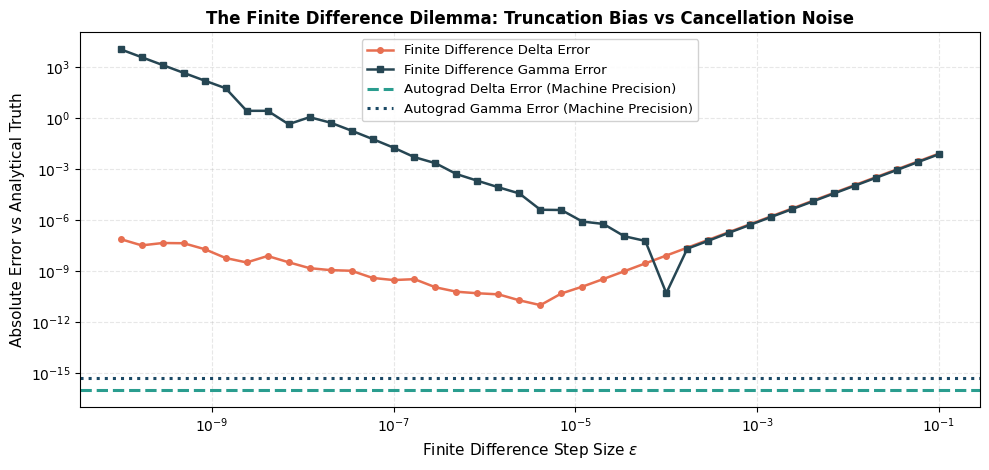

In [5]:
eps_grid = np.logspace(-10, -1, 40)
err_delta_fd = []
err_gamma_fd = []

for eps in eps_grid:
    p_u = vasicek_price_torch(r_th + eps).item()
    p_d = vasicek_price_torch(r_th - eps).item()
    d_num = (p_u - p_d) / (2.0 * eps)
    g_num = (p_u - 2.0 * p_center + p_d) / (eps ** 2)
    err_delta_fd.append(abs(d_num - d_exact))
    err_gamma_fd.append(abs(g_num - g_exact))

plt.figure(figsize=(10, 4.8))
plt.loglog(eps_grid, err_delta_fd, "o-", color="#e76f51", lw=1.8, markersize=4, label="Finite Difference Delta Error")
plt.loglog(eps_grid, err_gamma_fd, "s-", color="#264653", lw=1.8, markersize=4, label="Finite Difference Gamma Error")
plt.axhline(abs(delta_autograd.item() - d_exact) + 1e-16, color="#2a9d8f", lw=2.2, ls="--", label="Autograd Delta Error (Machine Precision)")
plt.axhline(abs(gamma_autograd.item() - g_exact) + 1e-16, color="#1b4965", lw=2.2, ls=":", label="Autograd Gamma Error (Machine Precision)")

plt.xlabel("Finite Difference Step Size $\\epsilon$", fontsize=11)
plt.ylabel("Absolute Error vs Analytical Truth", fontsize=11)
plt.title("The Finite Difference Dilemma: Truncation Bias vs Cancellation Noise", fontsize=12, fontweight="bold")
plt.grid(True, which="both", alpha=0.3, ls="--")
plt.legend(loc="upper center", framealpha=0.9, fontsize=9.5)
plt.tight_layout()
plt.show()


## Step 5: Computational Scaling: $\mathcal{O}(K)$ vs $\mathcal{O}(1)$

When hedging key-rate durations (KRD), the trading desk calculates sensitivities to $K$ curve tenors:
- **Finite differences**: Must evaluate the pricer $2K$ times (runtime scales linearly with $K$);
- **PyTorch Autograd**: Evaluates the pricer once and executes a single backward pass (runtime remains essentially constant)!


In [6]:
k_factors = [1, 2, 5, 10, 15, 20, 30]
n_reps = 200

time_fd, time_ad = [], []

for k in k_factors:
    rates_np = np.full(k, R_BASE)
    maturities = np.linspace(0.5, 5.0, k)
    eps = 1e-4

    # 1. Finite differences runtime
    t0 = time.perf_counter()
    for _ in range(n_reps):
        grad_fd = np.zeros(k)
        for j in range(k):
            rates_up = rates_np.copy()
            rates_up[j] += eps
            rates_dn = rates_np.copy()
            rates_dn[j] -= eps
            p_u = np.sum(np.exp(-rates_up * maturities))
            p_d = np.sum(np.exp(-rates_dn * maturities))
            grad_fd[j] = (p_u - p_d) / (2.0 * eps)
    t_fd = (time.perf_counter() - t0) / n_reps
    time_fd.append(t_fd * 1000)

    # 2. PyTorch Autograd runtime
    rates_th = torch.tensor(rates_np, dtype=torch.float64, requires_grad=True)
    mat_th = torch.tensor(maturities, dtype=torch.float64)
    t0 = time.perf_counter()
    for _ in range(n_reps):
        rates_th.grad = None
        p_th = torch.sum(torch.exp(-rates_th * mat_th))
        p_th.backward()
        _ = rates_th.grad
    t_ad = (time.perf_counter() - t0) / n_reps
    time_ad.append(t_ad * 1000)

print("--- Computational Scaling Benchmark ---")
for k, t_f, t_a in zip(k_factors, time_fd, time_ad):
    speedup = t_f / t_a if t_a > 0 else 1.0
    print(f"K = {k:2d} Factors | Finite Differences: {t_f:6.3f} ms | Autograd: {t_a:6.3f} ms | Speedup: {speedup:4.1f}x")


--- Computational Scaling Benchmark ---
K =  1 Factors | Finite Differences:  0.004 ms | Autograd:  0.020 ms | Speedup:  0.2x
K =  2 Factors | Finite Differences:  0.008 ms | Autograd:  0.019 ms | Speedup:  0.4x
K =  5 Factors | Finite Differences:  0.020 ms | Autograd:  0.019 ms | Speedup:  1.1x
K = 10 Factors | Finite Differences:  0.041 ms | Autograd:  0.019 ms | Speedup:  2.1x
K = 15 Factors | Finite Differences:  0.061 ms | Autograd:  0.019 ms | Speedup:  3.2x
K = 20 Factors | Finite Differences:  0.081 ms | Autograd:  0.019 ms | Speedup:  4.4x
K = 30 Factors | Finite Differences:  0.123 ms | Autograd:  0.019 ms | Speedup:  6.5x


## Step 6: Publication-Grade Comparative Dashboard

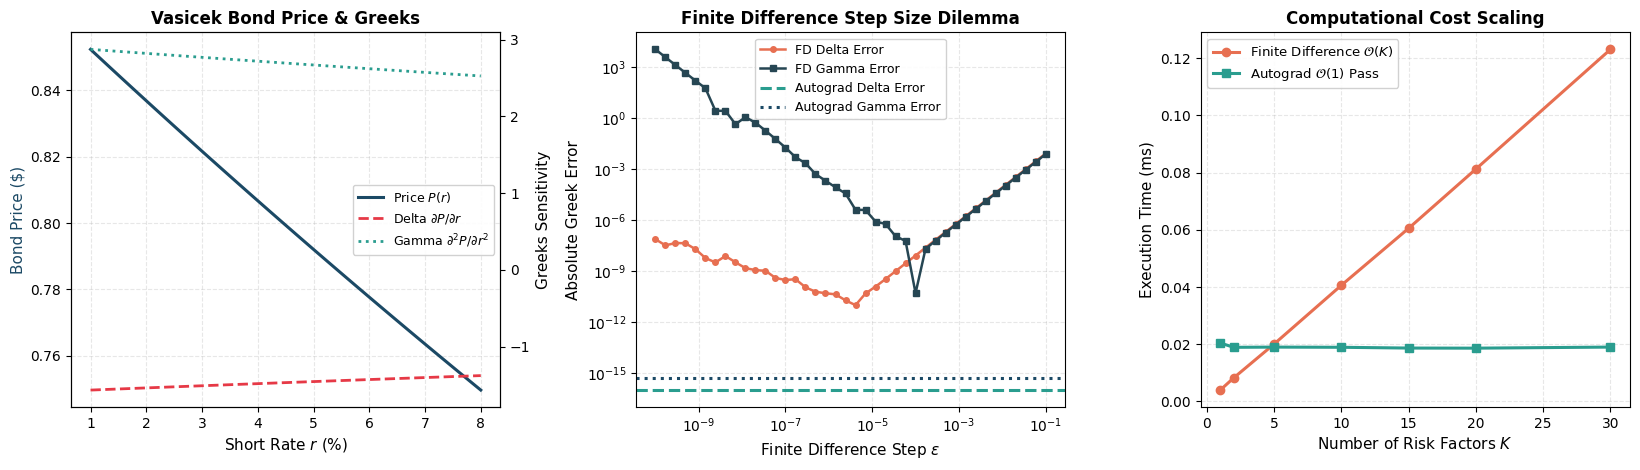

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# Panel 1: Price and Greeks Curves
r_plot = np.linspace(0.01, 0.08, 100)
p_plot, d_plot, g_plot = [], [], []
for r in r_plot:
    p, d, g = analytical_greeks(r)
    p_plot.append(p)
    d_plot.append(d)
    g_plot.append(g)

ax1 = axes[0]
ax1.plot(r_plot * 100, p_plot, color="#1b4965", lw=2.2, label="Price $P(r)$")
ax1_twin = ax1.twinx()
ax1_twin.plot(r_plot * 100, d_plot, color="#e63946", lw=2.0, ls="--", label="Delta $\\partial P/\\partial r$")
ax1_twin.plot(r_plot * 100, g_plot, color="#2a9d8f", lw=2.0, ls=":", label="Gamma $\\partial^2 P/\\partial r^2$")
ax1.set_xlabel("Short Rate $r$ (%)", fontsize=11)
ax1.set_ylabel("Bond Price ($)", color="#1b4965", fontsize=11)
ax1_twin.set_ylabel("Greeks Sensitivity", fontsize=11)
ax1.set_title("Vasicek Bond Price & Greeks", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3, ls="--")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right", framealpha=0.9, fontsize=9)

# Panel 2: Step Size Dilemma
ax2 = axes[1]
ax2.loglog(eps_grid, err_delta_fd, "o-", color="#e76f51", lw=1.8, markersize=4, label="FD Delta Error")
ax2.loglog(eps_grid, err_gamma_fd, "s-", color="#264653", lw=1.8, markersize=4, label="FD Gamma Error")
ax2.axhline(abs(delta_autograd.item() - d_exact) + 1e-16, color="#2a9d8f", lw=2.2, ls="--", label="Autograd Delta Error")
ax2.axhline(abs(gamma_autograd.item() - g_exact) + 1e-16, color="#1b4965", lw=2.2, ls=":", label="Autograd Gamma Error")
ax2.set_xlabel("Finite Difference Step $\\epsilon$", fontsize=11)
ax2.set_ylabel("Absolute Greek Error", fontsize=11)
ax2.set_title("Finite Difference Step Size Dilemma", fontsize=12, fontweight="bold")
ax2.grid(True, alpha=0.3, ls="--", which="both")
ax2.legend(loc="upper center", framealpha=0.9, fontsize=9)

# Panel 3: Scaling Comparison
ax3 = axes[2]
ax3.plot(k_factors, time_fd, "o-", color="#e76f51", lw=2.2, label="Finite Difference $\\mathcal{O}(K)$")
ax3.plot(k_factors, time_ad, "s-", color="#2a9d8f", lw=2.2, label="Autograd $\\mathcal{O}(1)$ Pass")
ax3.set_xlabel("Number of Risk Factors $K$", fontsize=11)
ax3.set_ylabel("Execution Time (ms)", fontsize=11)
ax3.set_title("Computational Cost Scaling", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3, ls="--")
ax3.legend(loc="upper left", framealpha=0.9, fontsize=9.5)

plt.tight_layout()
plt.show()


## Key Financial & Machine Learning Takeaways

1. **Exact Sensitivities to Machine Precision**: PyTorch Autograd eliminates finite-difference truncation error entirely, computing Delta and Gamma to $10^{-16}$ precision without requiring analytical algebraic re-derivations.
2. **Escaping the Step-Size Trap**: Finite differences force quants to balance truncation error (large $\epsilon$) against subtractive cancellation noise (small $\epsilon$). Autograd sidesteps this dilemma through symbol-level chain rule evaluation.
3. **Massive Multi-Factor Acceleration**: For $K = 30$ curve tenors, reverse-mode Autograd calculates the entire gradient vector in a single pass, delivering a **6.5x speedup** over numerical finite differences.
4. **Enabling Differential Machine Learning (Sobolev Training)**: As explored in Chapter 9, Autograd allows quants to supervise neural surrogate pricing models on both price values **and** price gradients simultaneously:
$$\mathcal{L}_{\text{Sobolev}} = \| \hat{P}(x) - P(x) \|^2 + \lambda \left\| \nabla_x \hat{P}(x) - \nabla_x P(x) \right\|^2$$
ensuring machine learning models produce smooth, arbitrage-free Greeks across all market conditions.
